<a href="https://colab.research.google.com/github/archangel2006/Quantinel/blob/main/4a_quantum_closed_world_attack_characterization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Quantum Closed-World Characterization**

*Can quantum kernel embeddings effectively characterize known network intrusions into the four NSL-KDD attack families under a closed-world setting?*

## **Imports**

In [99]:
# %pip install -U \
# qiskit \
# qiskit-machine-learning \
# qiskit-aer \
# pylatexenc \
# matplotlib

print("done")

done


In [100]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler
)

from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_classif,
    SelectKBest
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Quantum
from qiskit.circuit.library import ZZFeatureMap

from qiskit_machine_learning.kernels import FidelityQuantumKernel

from qiskit_machine_learning.algorithms import QSVC

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## **Load Datatsets**

In [101]:
import pandas as pd

train = pd.read_csv("KDDTrain.csv")
test = pd.read_csv("KDDTest.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

train.head()

Train Shape : (125973, 43)
Test Shape  : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


### **Map Attacks to Attack Families**

In [102]:

dos = [
    "back","land","neptune","pod",
    "smurf","teardrop"
]

probe = [
    "ipsweep","nmap",
    "portsweep","satan"
]

r2l = [
    "ftp_write","guess_passwd","imap",
    "multihop","phf","spy",
    "warezclient","warezmaster"
]

u2r = [
    "buffer_overflow",
    "loadmodule",
    "perl",
    "rootkit"
]


family_map = {}

for a in dos:
    family_map[a]="dos"

for a in probe:
    family_map[a]="probe"

for a in r2l:
    family_map[a]="r2l"

for a in u2r:
    family_map[a]="u2r"

train["family"] = train["label"].map(family_map)

attack_df = train.dropna(subset=["family"]).copy()

print("Attack Records :",attack_df.shape[0])

print()

print(attack_df["family"].value_counts())

Attack Records : 58630

family
dos      45927
probe    11656
r2l        995
u2r         52
Name: count, dtype: int64


In [103]:
# Dataset A: DoS + Probe + R2L


dataset_A = attack_df[
    attack_df["family"]!="u2r"
].copy()

df1 = dataset_A.copy()



# Dataset B: Includes U2R


dataset_B = attack_df.copy()

df2 = dataset_B.copy()


# Print

print("Dataset A")

print(dataset_A.family.value_counts())

print()

print("Dataset B")

print(dataset_B.family.value_counts())

Dataset A
family
dos      45927
probe    11656
r2l        995
Name: count, dtype: int64

Dataset B
family
dos      45927
probe    11656
r2l        995
u2r         52
Name: count, dtype: int64


### **Working Datatset**

In [104]:
# Dataset 1

x1 = df1.drop(
    columns=[
        "label",
        "difficulty_level",
        "family"
    ]
)

y1 = df1["family"]

# Dataset 2

x2 = df2.drop(
    columns=[
        "label",
        "difficulty_level",
        "family"
    ]
)

y2 = df2["family"]

print("Dataset 1:", x1.shape)
print("Dataset 2:", x2.shape)

Dataset 1: (58578, 41)
Dataset 2: (58630, 41)


## **OneHot Encoding + MinMax Scaling**


In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler


cat_cols = [
    "protocol_type",
    "service",
    "flag"
]



# Dataset A

num_cols1 = [
    c
    for c in x1.columns
    if c not in cat_cols
]

preprocessor1 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "num",
            MinMaxScaler(),
            num_cols1
        )
    ]
)

x_processed1 = preprocessor1.fit_transform(x1)

feature_names1 = preprocessor1.get_feature_names_out()

x_processed1 = pd.DataFrame(
    x_processed1,
    columns=feature_names1
)

print("Dataset A Encoded Shape :", x_processed1.shape)



# Dataset B

num_cols2 = [
    c
    for c in x2.columns
    if c not in cat_cols
]

preprocessor2 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "num",
            MinMaxScaler(),
            num_cols2
        )
    ]
)

x_processed2 = preprocessor2.fit_transform(x2)

feature_names2 = preprocessor2.get_feature_names_out()

x_processed2 = pd.DataFrame(
    x_processed2,
    columns=feature_names2
)

print("Dataset B Encoded Shape :", x_processed2.shape)



Dataset A Encoded Shape : (58578, 118)
Dataset B Encoded Shape : (58630, 118)


In [106]:
x_processed1.head()

,cat__protocol_type_icmp,cat__protocol_type_tcp,cat__protocol_type_udp,cat__service_IRC,cat__service_X11,cat__service_Z39_50,cat__service_aol,cat__service_auth,cat__service_bgp,cat__service_courier,...,num__dst_host_count,num__dst_host_srv_count,num__dst_host_same_srv_rate,num__dst_host_diff_srv_rate,num__dst_host_same_src_port_rate,num__dst_host_srv_diff_host_rate,num__dst_host_serror_rate,num__dst_host_srv_serror_rate,num__dst_host_rerror_rate,num__dst_host_srv_rerror_rate
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.098425,0.10,0.05,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.070866,0.07,0.07,0.0,0.0,0.0,0.0,1.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.031496,0.04,0.05,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.055118,0.06,0.07,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.086614,0.09,0.05,0.0,0.0,1.0,1.0,0.0,0.0


In [107]:
x_processed2.head()

,cat__protocol_type_icmp,cat__protocol_type_tcp,cat__protocol_type_udp,cat__service_IRC,cat__service_X11,cat__service_Z39_50,cat__service_aol,cat__service_auth,cat__service_bgp,cat__service_courier,...,num__dst_host_count,num__dst_host_srv_count,num__dst_host_same_srv_rate,num__dst_host_diff_srv_rate,num__dst_host_same_src_port_rate,num__dst_host_srv_diff_host_rate,num__dst_host_serror_rate,num__dst_host_srv_serror_rate,num__dst_host_rerror_rate,num__dst_host_srv_rerror_rate
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.098425,0.10,0.05,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.070866,0.07,0.07,0.0,0.0,0.0,0.0,1.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.031496,0.04,0.05,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.055118,0.06,0.07,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.086614,0.09,0.05,0.0,0.0,1.0,1.0,0.0,0.0


## **Remove Near-Constant Features**

In [108]:
from sklearn.feature_selection import VarianceThreshold


# Dataset A

print("Dataset A - Original Features :", x_processed1.shape[1])

var_filter1 = VarianceThreshold(
    threshold=0.01
)

x_var1 = var_filter1.fit_transform(x_processed1)

selected_features1 = x_processed1.columns[
    var_filter1.get_support()
]

x_var1 = pd.DataFrame(
    x_var1,
    columns=selected_features1
)

print("Dataset A - Remaining Features :", x_var1.shape[1])



# Dataset B

print("\nDataset B - Original Features :", x_processed2.shape[1])

var_filter2 = VarianceThreshold(
    threshold=0.01
)

x_var2 = var_filter2.fit_transform(x_processed2)

selected_features2 = x_processed2.columns[
    var_filter2.get_support()
]

x_var2 = pd.DataFrame(
    x_var2,
    columns=selected_features2
)

print("Dataset B - Remaining Features :", x_var2.shape[1])

Dataset A - Original Features : 118
Dataset A - Remaining Features : 49

Dataset B - Original Features : 118
Dataset B - Remaining Features : 49


## **Remove Highly Correlated Features**


In [109]:
# Dataset A

corr_matrix1 = x_var1.corr().abs()

upper1 = corr_matrix1.where(
    np.triu(
        np.ones(corr_matrix1.shape),
        k=1
    ).astype(bool)
)

drop_cols1 = [
    column
    for column in upper1.columns
    if any(
        upper1[column] > 0.95
    )
]

print("Dataset A - Highly Correlated Features :", len(drop_cols1))

x_corr1 = x_var1.drop(
    columns=drop_cols1
)

print("Dataset A - Remaining Features :", x_corr1.shape[1])



# Dataset B

corr_matrix2 = x_var2.corr().abs()

upper2 = corr_matrix2.where(
    np.triu(
        np.ones(corr_matrix2.shape),
        k=1
    ).astype(bool)
)

drop_cols2 = [
    column
    for column in upper2.columns
    if any(
        upper2[column] > 0.95
    )
]

print("\nDataset B - Highly Correlated Features :", len(drop_cols2))

x_corr2 = x_var2.drop(
    columns=drop_cols2
)

print("Dataset B - Remaining Features :", x_corr2.shape[1])

Dataset A - Highly Correlated Features : 6
Dataset A - Remaining Features : 43

Dataset B - Highly Correlated Features : 6
Dataset B - Remaining Features : 43


In [110]:
display(x_corr1.head())
display(x_corr2.head())

,cat__protocol_type_icmp,cat__protocol_type_tcp,cat__protocol_type_udp,cat__service_Z39_50,cat__service_auth,cat__service_bgp,cat__service_courier,cat__service_eco_i,cat__service_ecr_i,cat__service_finger,...,num__same_srv_rate,num__diff_srv_rate,num__srv_diff_host_rate,num__dst_host_count,num__dst_host_srv_count,num__dst_host_same_srv_rate,num__dst_host_diff_srv_rate,num__dst_host_same_src_port_rate,num__dst_host_srv_diff_host_rate,num__dst_host_rerror_rate
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.07,0.0,1.0,0.098425,0.10,0.05,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.16,0.06,0.0,1.0,0.070866,0.07,0.07,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.06,0.0,1.0,0.031496,0.04,0.05,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.14,0.06,0.0,1.0,0.055118,0.06,0.07,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.09,0.05,0.0,1.0,0.086614,0.09,0.05,0.0,0.0,0.0


,cat__protocol_type_icmp,cat__protocol_type_tcp,cat__protocol_type_udp,cat__service_Z39_50,cat__service_auth,cat__service_bgp,cat__service_courier,cat__service_eco_i,cat__service_ecr_i,cat__service_finger,...,num__same_srv_rate,num__diff_srv_rate,num__srv_diff_host_rate,num__dst_host_count,num__dst_host_srv_count,num__dst_host_same_srv_rate,num__dst_host_diff_srv_rate,num__dst_host_same_src_port_rate,num__dst_host_srv_diff_host_rate,num__dst_host_rerror_rate
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.07,0.0,1.0,0.098425,0.10,0.05,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.16,0.06,0.0,1.0,0.070866,0.07,0.07,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.06,0.0,1.0,0.031496,0.04,0.05,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.14,0.06,0.0,1.0,0.055118,0.06,0.07,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.09,0.05,0.0,1.0,0.086614,0.09,0.05,0.0,0.0,0.0


## **Top Informative Features**


Feature selection is performed once on the closed-world dataset. The resulting feature rankings are also used for Dataset B since the inclusion of 52 U2R samples produces negligible changes in Mutual Information.

In [111]:
from sklearn.feature_selection import mutual_info_classif


mi_scores = mutual_info_classif(
    x_corr1,
    y1,
    random_state=42
)

mi = pd.Series(
    mi_scores,
    index=x_corr1.columns
)

mi = mi.sort_values(
    ascending=False
)

print("Top 20 Features")
display(mi.head(20))

Top 20 Features


,0
num__dst_host_diff_srv_rate,0.355595
num__count,0.316533
num__diff_srv_rate,0.314197
cat__flag_S0,0.230182
num__same_srv_rate,0.225018
num__dst_host_same_src_port_rate,0.223524
num__srv_count,0.208817
num__dst_host_same_srv_rate,0.203977
num__dst_host_srv_count,0.179202
num__dst_host_count,0.157293


In [112]:
mi.to_csv("mutual_information_scores.csv")

## **Select Top 8 Features**


In [113]:
TOP_K = 8

top_features = mi.head(TOP_K).index.tolist()

print("Selected Features")

for i, f in enumerate(top_features, 1):
    print(f"{i}. {f}")

# Dataset A
x_selected = x_corr1[
    top_features
].copy()

# Dataset B
x_selected2 = x_corr2[
    top_features
].copy()

print()

print("Dataset A Final Quantum Shape")
print(x_selected.shape)

print()

print("Dataset B Final Quantum Shape")
print(x_selected2.shape)

Selected Features
1. num__dst_host_diff_srv_rate
2. num__count
3. num__diff_srv_rate
4. cat__flag_S0
5. num__same_srv_rate
6. num__dst_host_same_src_port_rate
7. num__srv_count
8. num__dst_host_same_srv_rate

Dataset A Final Quantum Shape
(58578, 8)

Dataset B Final Quantum Shape
(58630, 8)


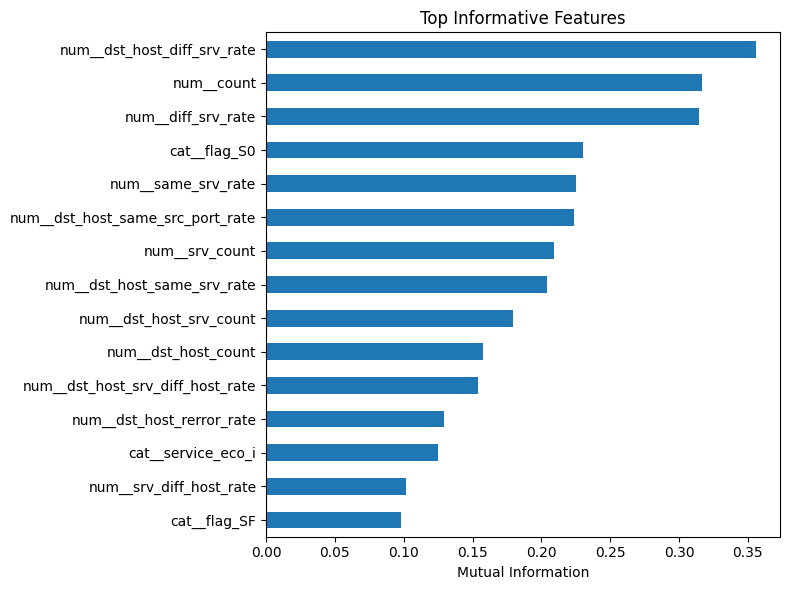

In [114]:
plt.figure(figsize=(8,6))

mi.head(15).sort_values().plot(kind="barh")

plt.xlabel("Mutual Information")
plt.title("Top Informative Features")

plt.tight_layout()

plt.savefig(
    "top_features.png",
    dpi=300
)

plt.show()

| Feature                         | Why it's useful                                                                         |
| ------------------------------- | --------------------------------------------------------------------------------------- |
| **flag_S0**                     | Connection status. S0 means SYN sent but no reply. Very discriminative for DoS attacks. |
| **count**                       | Number of connections to the same host. Excellent attack indicator.                     |
| **srv_count**                   | Connections to same service. Separates scanning vs flooding.                            |
| **same_srv_rate**               | Fraction of same-service connections. Important for attack behavior.                    |
| **diff_srv_rate**               | Fraction of different-service connections. Very useful for Probe attacks.               |
| **dst_host_same_srv_rate**      | Destination host service consistency. Common IDS feature.                               |
| **dst_host_diff_srv_rate**      | Destination host diversity. Helps distinguish Probe/R2L.                                |
| **dst_host_same_src_port_rate** | Source-port reuse pattern. Another classical intrusion feature.                         |


The algorithm selected them using:

- Variance filtering
- Correlation filtering
- Mutual Information



> *After removing low-variance and highly correlated features, Mutual Information was employed to retain the eight most informative engineered network features for quantum embedding.*

## **Balanced Quantum Dataset**


In [115]:
# Dataset A (DoS + Probe + R2L)

quantum_df1 = x_selected.copy()
quantum_df1["family"] = y1.values

dos1 = quantum_df1[quantum_df1.family == "dos"].sample(
    120,
    random_state=42
)

probe1 = quantum_df1[quantum_df1.family == "probe"].sample(
    120,
    random_state=42
)

r2l1 = quantum_df1[quantum_df1.family == "r2l"].sample(
    120,
    random_state=42
)

quantum_df1 = pd.concat([
    dos1,
    probe1,
    r2l1
]).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X1 = quantum_df1.drop(columns="family")
Y1 = quantum_df1["family"]

print("Dataset A")
print(X1.shape)
print(Y1.value_counts())


Dataset A
(360, 8)
family
probe    120
dos      120
r2l      120
Name: count, dtype: int64


In [116]:
# Dataset B (DoS + Probe + R2L + U2R)

quantum_df2 = x_selected2.copy()
quantum_df2["family"] = y2.values

dos2 = quantum_df2[quantum_df2.family == "dos"].sample(
    120,
    random_state=42
)

probe2 = quantum_df2[quantum_df2.family == "probe"].sample(
    120,
    random_state=42
)

r2l2 = quantum_df2[quantum_df2.family == "r2l"].sample(
    120,
    random_state=42
)

# Use all available U2R samples (52)
u2r2 = quantum_df2[quantum_df2.family == "u2r"]

quantum_df2 = pd.concat([
    dos2,
    probe2,
    r2l2,
    u2r2
]).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X2 = quantum_df2.drop(columns="family")
Y2 = quantum_df2["family"]

print("\nDataset B")
print(X2.shape)
print(Y2.value_counts())


Dataset B
(412, 8)
family
r2l      120
dos      120
probe    120
u2r       52
Name: count, dtype: int64


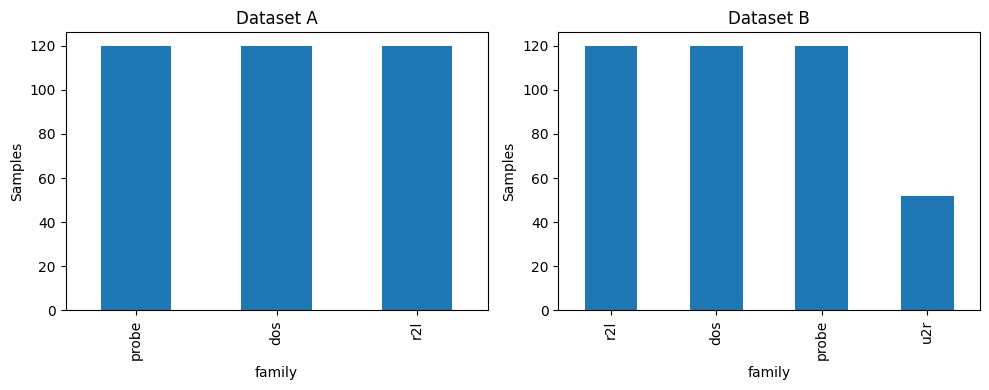

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

Y1.value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Dataset A")
axes[0].set_ylabel("Samples")

Y2.value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Dataset B")
axes[1].set_ylabel("Samples")

plt.tight_layout()
plt.savefig(
    "balanced_datasets.png",
    dpi=300
)
plt.show()

## **Train/Test Split**


In [118]:
from sklearn.model_selection import train_test_split

# ---------- Dataset A ----------
x_train1, x_test1, y_train1, y_test1 = train_test_split(
    X1,
    Y1,
    test_size=0.30,
    stratify=Y1,
    random_state=42
)

print("Dataset A")
print("Train Shape :", x_train1.shape)
print("Test Shape  :", x_test1.shape)

print("\nTraining Distribution")
print(y_train1.value_counts())

print("\nTesting Distribution")
print(y_test1.value_counts())


Dataset A
Train Shape : (252, 8)
Test Shape  : (108, 8)

Training Distribution
family
dos      84
probe    84
r2l      84
Name: count, dtype: int64

Testing Distribution
family
r2l      36
probe    36
dos      36
Name: count, dtype: int64


In [119]:
# ---------- Dataset B ----------
x_train2, x_test2, y_train2, y_test2 = train_test_split(
    X2,
    Y2,
    test_size=0.30,
    stratify=Y2,
    random_state=42
)

print("\n---------------------------")
print("Dataset B")
print("Train Shape :", x_train2.shape)
print("Test Shape  :", x_test2.shape)

print("\nTraining Distribution")
print(y_train2.value_counts())

print("\nTesting Distribution")
print(y_test2.value_counts())


---------------------------
Dataset B
Train Shape : (288, 8)
Test Shape  : (124, 8)

Training Distribution
family
r2l      84
dos      84
probe    84
u2r      36
Name: count, dtype: int64

Testing Distribution
family
r2l      36
probe    36
dos      36
u2r      16
Name: count, dtype: int64


## **Quantum Feature Map**

In [120]:


from qiskit.circuit.library import ZZFeatureMap

feature_map = ZZFeatureMap(
    feature_dimension=x_train1.shape[1],
    reps=1
)

print(feature_map)

fig = feature_map.decompose().draw("mpl")

fig.savefig(
    "ZZFeatureMap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

     ┌────────────────────────────────────────────────────────┐
q_0: ┤0                                                       ├
     │                                                        │
q_1: ┤1                                                       ├
     │                                                        │
q_2: ┤2                                                       ├
     │                                                        │
q_3: ┤3                                                       ├
     │  ZZFeatureMap(x[0],x[1],x[2],x[3],x[4],x[5],x[6],x[7]) │
q_4: ┤4                                                       ├
     │                                                        │
q_5: ┤5                                                       ├
     │                                                        │
q_6: ┤6                                                       ├
     │                                                        │
q_7: ┤7                                 

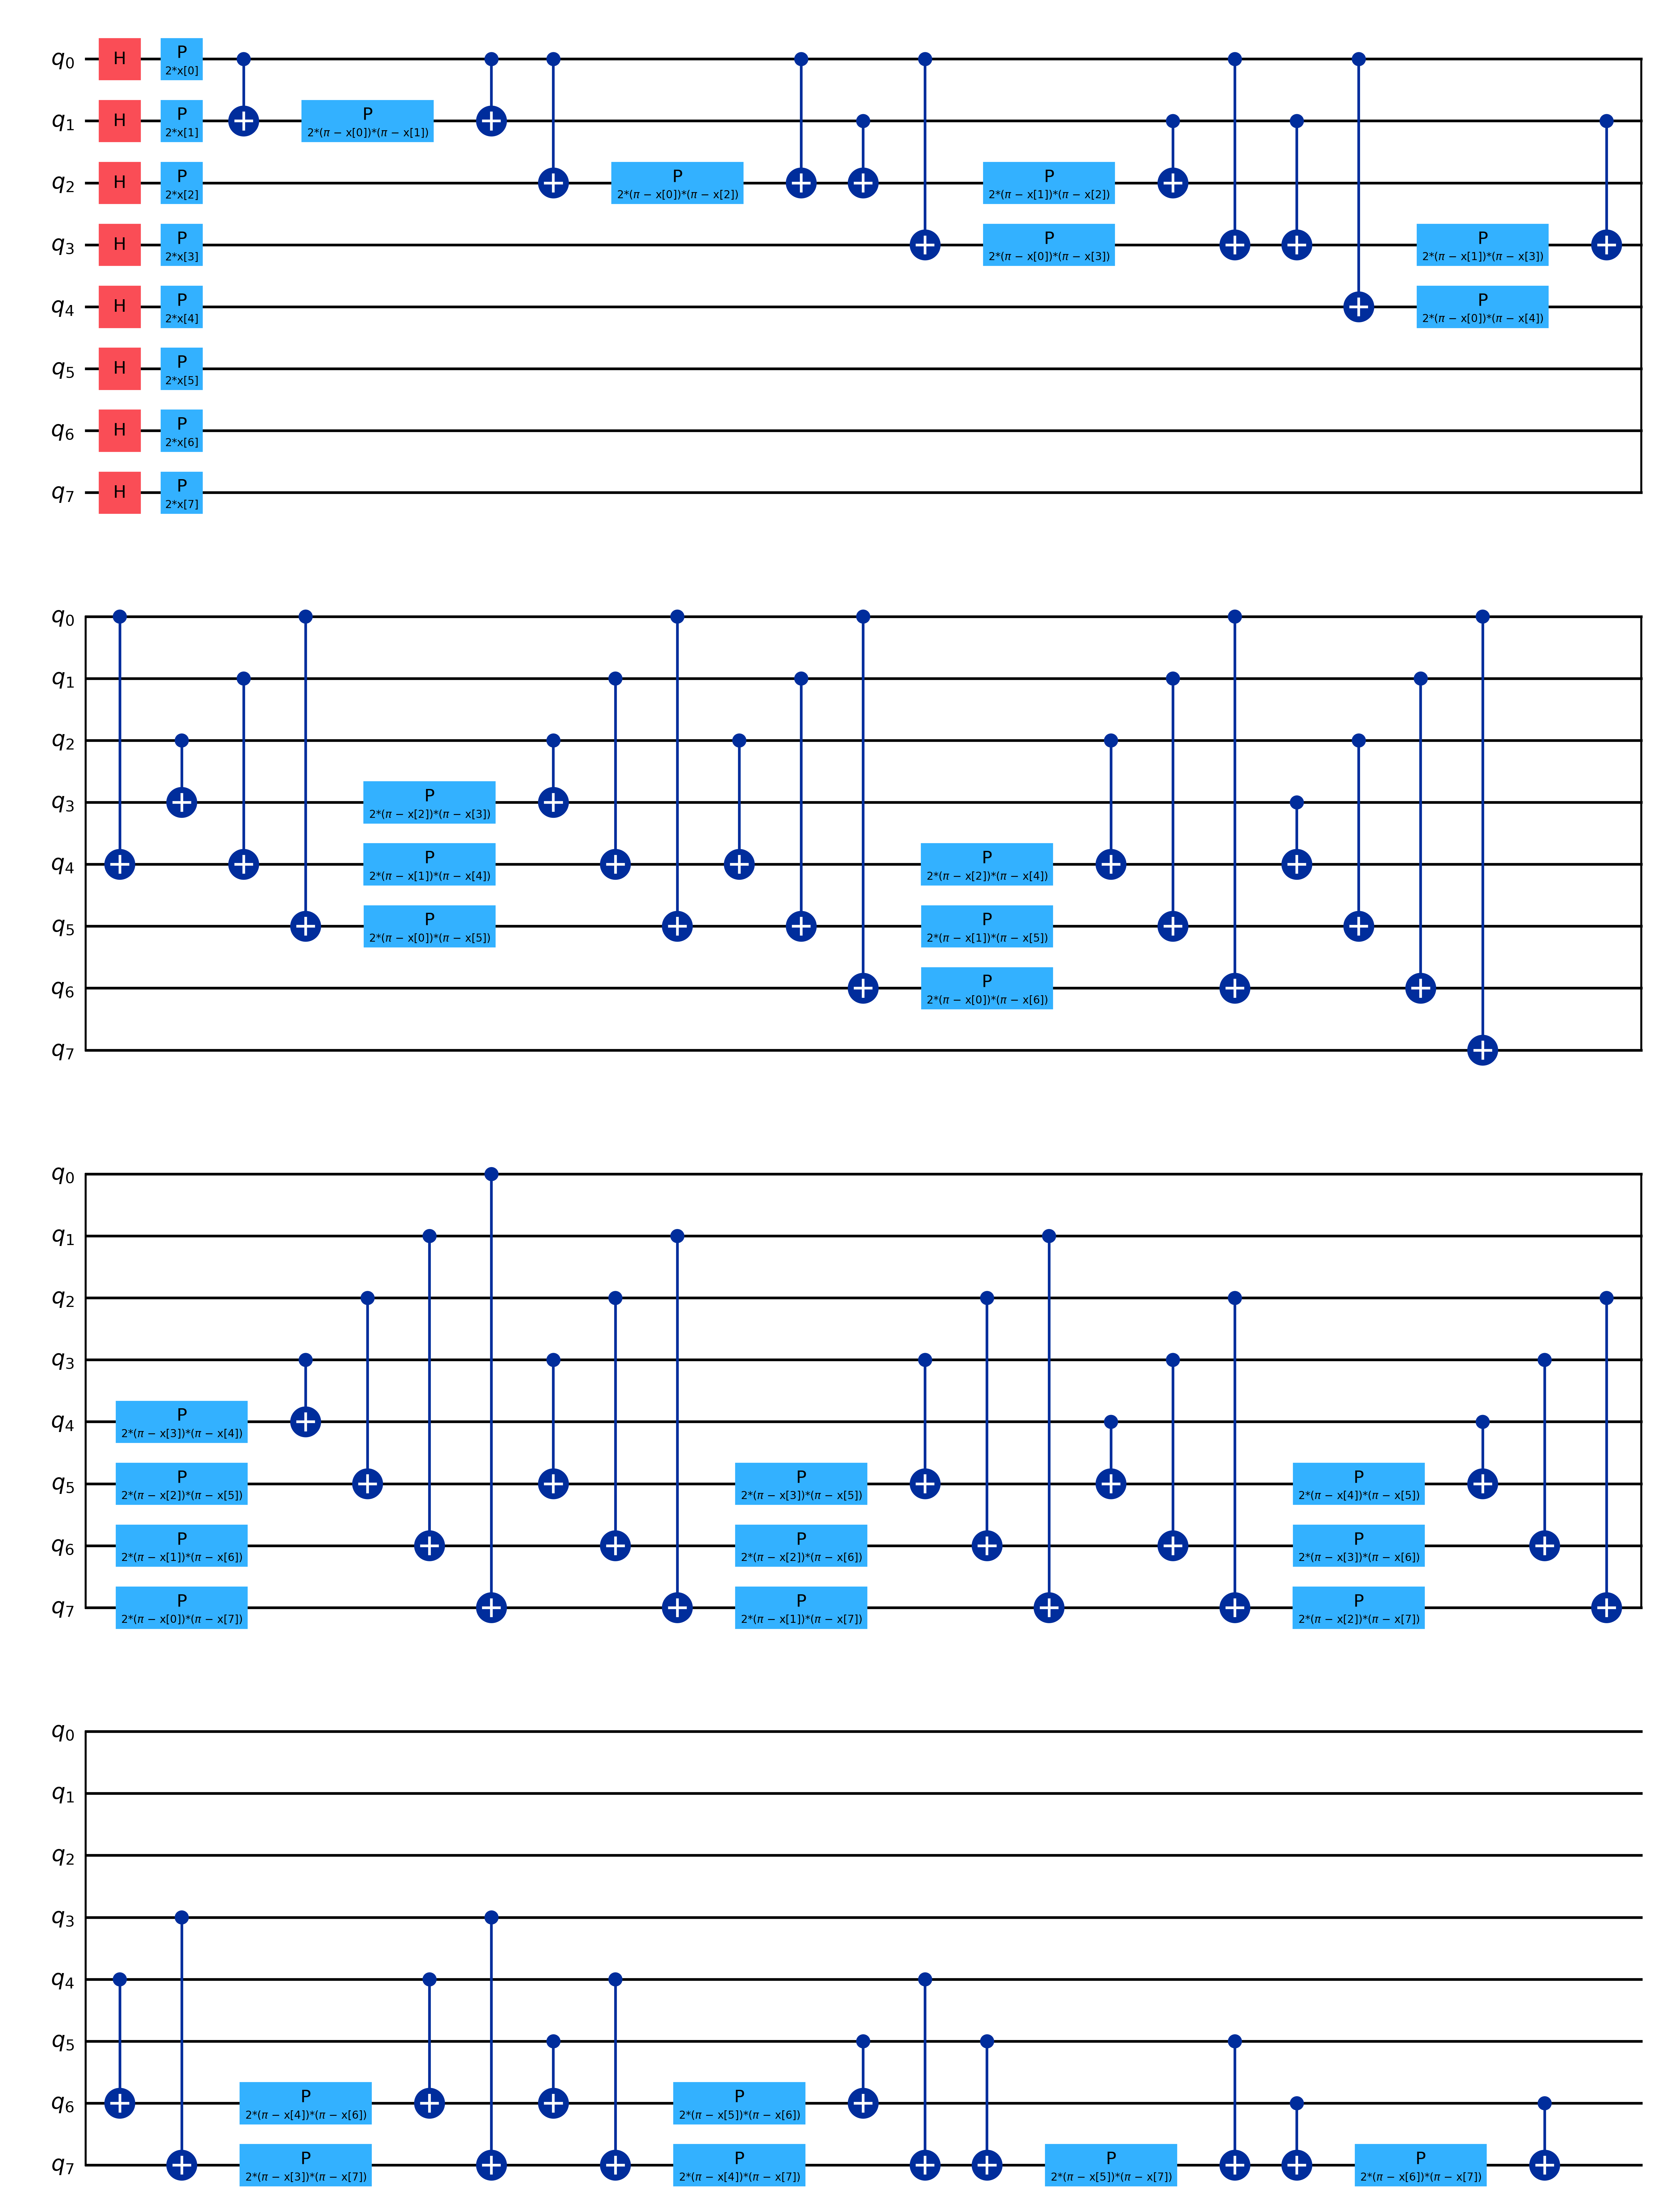

In [121]:
import qiskit
import qiskit_machine_learning

print(qiskit.__version__)
print(qiskit_machine_learning.__version__)

2.5.0
0.9.0


In [122]:
print("Dataset A")
print(x_train1.shape)
print(type(x_train1))

print(y_train1.shape)
print(y_train1.value_counts())

Dataset A
(252, 8)
<class 'pandas.core.frame.DataFrame'>
(252,)
family
dos      84
probe    84
r2l      84
Name: count, dtype: int64


In [123]:
print("Dataset B")
print(x_train2.shape)
print(type(x_train2))

print(y_train2.shape)
print(y_train2.value_counts())

Dataset B
(288, 8)
<class 'pandas.core.frame.DataFrame'>
(288,)
family
r2l      84
dos      84
probe    84
u2r      36
Name: count, dtype: int64


In [124]:
print(np.isnan(x_train1).sum())
print(np.isinf(x_train1).sum())

num__dst_host_diff_srv_rate         0
num__count                          0
num__diff_srv_rate                  0
cat__flag_S0                        0
num__same_srv_rate                  0
num__dst_host_same_src_port_rate    0
num__srv_count                      0
num__dst_host_same_srv_rate         0
dtype: int64
num__dst_host_diff_srv_rate         0
num__count                          0
num__diff_srv_rate                  0
cat__flag_S0                        0
num__same_srv_rate                  0
num__dst_host_same_src_port_rate    0
num__srv_count                      0
num__dst_host_same_srv_rate         0
dtype: int64


In [125]:
print(np.isnan(x_train2).sum())
print(np.isinf(x_train2).sum())

num__dst_host_diff_srv_rate         0
num__count                          0
num__diff_srv_rate                  0
cat__flag_S0                        0
num__same_srv_rate                  0
num__dst_host_same_src_port_rate    0
num__srv_count                      0
num__dst_host_same_srv_rate         0
dtype: int64
num__dst_host_diff_srv_rate         0
num__count                          0
num__diff_srv_rate                  0
cat__flag_S0                        0
num__same_srv_rate                  0
num__dst_host_same_src_port_rate    0
num__srv_count                      0
num__dst_host_same_srv_rate         0
dtype: int64


In [126]:
print(feature_map.num_qubits)

8


## **Fidelity Quantum Kernel Construction**

In [127]:
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

sampler = StatevectorSampler()

fidelity = ComputeUncompute(
    sampler=sampler
)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map,
    fidelity=fidelity
)

print("Kernel Ready")

Kernel Ready


In [128]:
import qiskit_aer
print(qiskit_aer.__version__)

0.17.2


In [129]:
from time import time

start = time()

K = quantum_kernel.evaluate(x_train1.iloc[:20])

print("Time:", time()-start)

Time: 3.1418726444244385


In [130]:
print(type(quantum_kernel))
print(type(feature_map))

<class 'qiskit_machine_learning.kernels.fidelity_quantum_kernel.FidelityQuantumKernel'>
<class 'qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap'>


In [131]:
import time

start = time.time()
K = quantum_kernel.evaluate(x_train1.iloc[:5])
print(time.time() - start)

0.16375136375427246


## **QSVC Training**

In [132]:
from qiskit_machine_learning.algorithms import QSVC


# ---------- Dataset A ----------
qsvc1 = QSVC(
    quantum_kernel=quantum_kernel
)

print("Training QSVC - Dataset A...")

qsvc1.fit(
    x_train1,
    y_train1
)

print("Dataset A Training Complete.")


# ---------- Dataset B ----------
qsvc2 = QSVC(
    quantum_kernel=quantum_kernel
)

print("\nTraining QSVC - Dataset B...")

qsvc2.fit(
    x_train2,
    y_train2
)

print("Dataset B Training Complete.")

Training QSVC - Dataset A...
Dataset A Training Complete.

Training QSVC - Dataset B...
Dataset B Training Complete.


## **Prediction**

In [133]:
# Dataset A
y_pred1 = qsvc1.predict(x_test1)

print("Dataset A Predictions")
print(y_pred1[:20])


# Dataset B
y_pred2 = qsvc2.predict(x_test2)

print("\nDataset B Predictions")
print(y_pred2[:20])

Dataset A Predictions
['r2l' 'r2l' 'probe' 'dos' 'probe' 'dos' 'r2l' 'dos' 'dos' 'dos' 'r2l'
 'probe' 'dos' 'r2l' 'r2l' 'r2l' 'r2l' 'r2l' 'probe' 'dos']

Dataset B Predictions
['r2l' 'probe' 'dos' 'r2l' 'probe' 'dos' 'r2l' 'dos' 'probe' 'dos' 'u2r'
 'probe' 'r2l' 'r2l' 'r2l' 'probe' 'dos' 'probe' 'u2r' 'r2l']


## **Accuracy**

In [134]:
from sklearn.metrics import accuracy_score

acc1 = accuracy_score(
    y_test1,
    y_pred1
)

acc2 = accuracy_score(
    y_test2,
    y_pred2
)

print(f"Dataset A QSVC Accuracy : {acc1:.4f}")
print(f"Dataset B QSVC Accuracy : {acc2:.4f}")

Dataset A QSVC Accuracy : 0.8981
Dataset B QSVC Accuracy : 0.8548


## **Classification Report**

In [135]:
from sklearn.metrics import classification_report

# Dataset A

print("Dataset A")

print(
    classification_report(
        y_test1,
        y_pred1
    )
)


# Dataset B

print("\nDataset B")

print(
    classification_report(
        y_test2,
        y_pred2
    )
)

Dataset A
              precision    recall  f1-score   support

         dos       0.90      1.00      0.95        36
       probe       0.97      0.83      0.90        36
         r2l       0.84      0.86      0.85        36

    accuracy                           0.90       108
   macro avg       0.90      0.90      0.90       108
weighted avg       0.90      0.90      0.90       108


Dataset B
              precision    recall  f1-score   support

         dos       1.00      0.94      0.97        36
       probe       0.94      0.89      0.91        36
         r2l       0.71      0.94      0.81        36
         u2r       0.75      0.38      0.50        16

    accuracy                           0.85       124
   macro avg       0.85      0.79      0.80       124
weighted avg       0.87      0.85      0.85       124



## **Confusion Matrix**

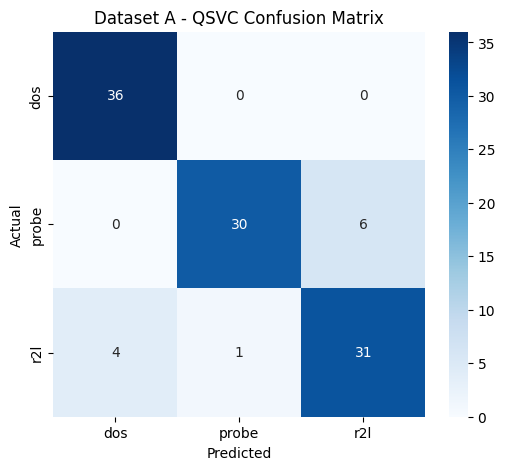

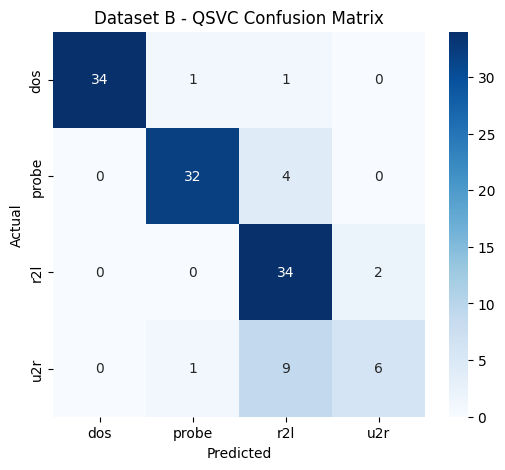

In [136]:
# Dataset A

cm1 = confusion_matrix(y_test1, y_pred1)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=qsvc1.classes_,
    yticklabels=qsvc1.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dataset A - QSVC Confusion Matrix")

plt.savefig(
    "qsvc_confusion_matrix_dataset_A.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Dataset B

cm2 = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=qsvc2.classes_,
    yticklabels=qsvc2.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dataset B - QSVC Confusion Matrix")

plt.savefig(
    "qsvc_confusion_matrix_dataset_B.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [137]:
# Dataset A

comparison1 = pd.DataFrame({
    "Actual": y_test1.values,
    "Predicted": y_pred1
})

comparison1.head(30)

comparison1.to_csv(
    "qsvc_predictions_dataset_A.csv",
    index=False
)


In [138]:
# Dataset B

comparison2 = pd.DataFrame({
    "Actual": y_test2.values,
    "Predicted": y_pred2
})

comparison2.head(30)

comparison2.to_csv(
    "qsvc_predictions_dataset_B.csv",
    index=False
)

# **Conclusion**

- The experimental results demonstrate that a carefully selected **8-feature** representation is sufficient for effective quantum-based intrusion characterization.


- On the **balanced closed-world dataset (DoS, Probe, and R2L)**, the proposed QSVC achieved approximately **90%** accuracy, successfully distinguishing the major attack families while maintaining strong class-wise performance.
- Including the highly **underrepresented U2R family** resulted in reduced overall performance of **85%**, highlighting the impact of severe class imbalance on quantum kernel-based classifiers.



Overall, these findings validate the applicability of quantum kernel methods for closed-world cyberattack characterization and provide a strong motivation for extending the study to open-world intrusion scenarios involving previously unseen attack types.